## Notebook 04 - RMS Energy Analysis
### Research Question
Can RMS Energy distinguish normal and abnormal pump recordings?

### Motivation
Waveform inspection suggested that some abnormal recordings appear visually similar to normal recordings.

This notebook investigates whether RMS Energy can serve as a simple anomaly indicator.

#### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import *
from src.dataset import *
from src.io import *
from src.feature import *
from src.visualization import *

In [5]:
paths = get_training_dataset_path()

normal_path = paths["normal"]
abnormal_path = paths["abnormal"]

In [6]:
normal_files = get_audio_files(normal_path)
abnormal_files = get_audio_files(abnormal_path)

In [7]:
print(f"Normal recordings: {len(normal_files)}")
print(f"Abnormal recordings: {len(abnormal_files)}")

Normal recordings: 1006
Abnormal recordings: 143


#### Computing RMS Energy

In [4]:
normal_rms = []
for file in normal_files:
    signal, sr = load_channel(file, channel)
    normal_rms.append(mean_rms(signal))
abnormal_rms = []
for file in abnormal_files:
    signal, sr = load_channel(file, channel)
    abnormal_rms.append(mean_rms(signal))

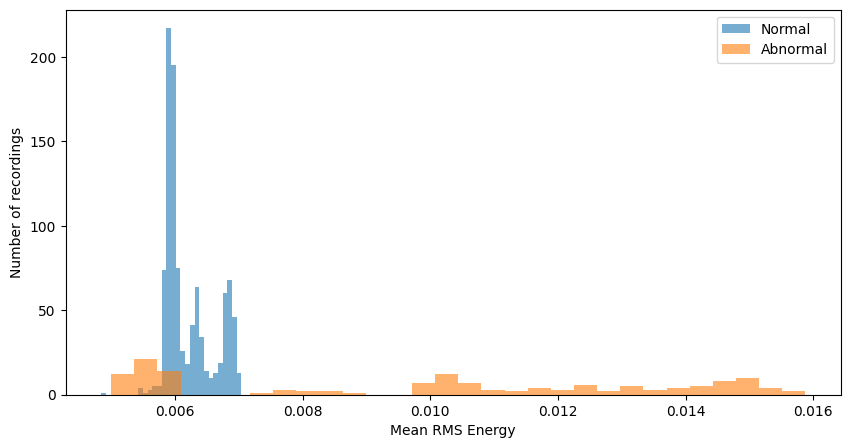

In [5]:
plt.figure(figsize = (10, 5))
plt.hist(normal_rms, bins = 30, alpha = 0.6, label= "Normal")
plt.hist(abnormal_rms, bins = 30, alpha = 0.6, label = "Abnormal")
plt.xlabel("Mean RMS Energy")
plt.ylabel("Number of recordings")
plt.legend()
plt.show()

<b>Observation: </b>
* There is a considerable overlap of abnormal files and normal files.
* There are very few outliers in Normal folder.
* the abnormal RMS distribuation is right-shifted relative to the normal distribuation, indicating that many abnormal recordings exhibit higher overall signal energy.
* The normal distribution is not perfectly unimodel. It appears to have three closely spaced peaks around the 0.006 region. This suggests that even under normal operating conditions, the pump does not produce a single, constant RMS level.
* Abnormal distribution is clearly multimodel.This indicates that the abnormal class is heterogeneous - it likely contains faults with different energy characteristics rather than one uniform type of anomaly.

In [7]:
summary = pd.DataFrame({
    "Normal": [
        np.mean(normal_rms),
        np.std(normal_rms),
        np.min(normal_rms),
        np.max(normal_rms),
        np.median(normal_rms)
    ],
    "Abnormal":[
        np.mean(abnormal_rms),
        np.std(abnormal_rms),
        np.min(abnormal_rms),
        np.max(abnormal_rms),
        np.median(abnormal_rms)
    ],
},
index = ["Mean", "Std", "Min", "Max", "Median"])
summary

,Normal,Abnormal
Mean,0.006205,0.010012
Std,0.000377,0.003622
Min,0.004839,0.005000
Max,0.007039,0.015876
Median,0.006010,0.010316


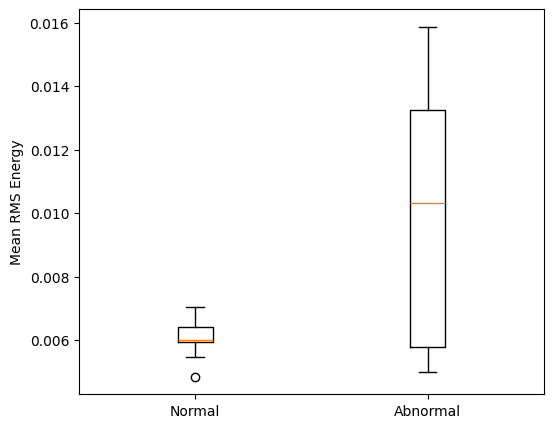

In [9]:
# Boxplot to check outliers
plt.figure(figsize = (6,5))
plt.boxplot([normal_rms, abnormal_rms], tick_labels = ["Normal", "Abnormal"])
plt.ylabel("Mean RMS Energy")
plt.show()

Would a simple threshold work?

In [10]:
normal_max = max(normal_rms)

abnormal_below = sum(
    r <= normal_max
    for r in abnormal_rms
)

print(abnormal_below)

47


<b>Observation</b>: In the above code we have taken the threshold value as<b> max of the normal's RMS Energy</b> and by the output we can say that out of 143 files there are <b>47 files that are not recognized by threshold</b> as they are below it - <b> they are our Overlapping Anomalies </b>

This concludes that we can use the threshold value based on the RMS energy to identify obvious anomalies but <b> for subtle and overlapping anomalies, it is not enough</b>

### Finding the Overlapping Files

In [12]:
records = []
# Normal files
for file in normal_files:
    signal, sr = load_channel(file, channel)
    rms_value = mean_rms(signal)
    records.append({"file_name": file.name, "label": "Normal", "rms": rms_value})

# Abnormal files
for file in abnormal_files:
    signal, sr = load_channel(file, channel)
    rms_value = mean_rms(signal)
    records.append({"file_name": file.name, "label": "Abnormal", "rms": rms_value})

rms_df = pd.DataFrame(records)
rms_df.head()

,file_name,label,rms
0,00000000.wav,Normal,0.006863
1,00000001.wav,Normal,0.006892
2,00000002.wav,Normal,0.007001
3,00000003.wav,Normal,0.006864
4,00000004.wav,Normal,0.006833


In [13]:
rms_df.tail()

,file_name,label,rms
1144,00000138.wav,Abnormal,0.013839
1145,00000139.wav,Abnormal,0.011610
1146,00000140.wav,Abnormal,0.010800
1147,00000141.wav,Abnormal,0.007232
1148,00000142.wav,Abnormal,0.005879


In [14]:
normal_min = rms_df[rms_df["label"] == "Normal"]["rms"].min()
normal_max = rms_df[rms_df["label"] == "Normal"]["rms"].max()

print(f"Normal RMS Range : ({normal_min:.8f}, {normal_max:.8f})")

Normal RMS Range : (0.00483859, 0.00703865)


In [15]:
overlap_df = rms_df[
    (rms_df["label"] == "Abnormal") &
    (rms_df["rms"] >= normal_min) &
    (rms_df["rms"] <= normal_max)
].copy()

overlap_df = overlap_df.sort_values(by="rms").reset_index(drop=True)

print(f"Number of overlapping anomalies: {len(overlap_df)}")

overlap_df.head()

Number of overlapping anomalies: 47


,file_name,label,rms
0,00000131.wav,Abnormal,0.005000
1,00000126.wav,Abnormal,0.005141
2,00000127.wav,Abnormal,0.005186
3,00000125.wav,Abnormal,0.005210
4,00000129.wav,Abnormal,0.005221


In [20]:
overlap_df.to_csv("C:/MyProjects/MIMIIResearch/EchoGuard/results/rms_overlap_files.csv", index = False)
rms_df.to_csv("C:/MyProjects/MIMIIResearch/EchoGuard/results/rms_summary.csv", index = False)

## Conclusions
* RMS Energy separated many obvious anomalies.
* A significant subset of abnormal recordings overlaps completely with normal recordings.
* No single threshold can perfectly classify the recordings.
* RMS Energy is therefore insufficient as a standalone feature.